# Decision Tree Classifier for Bank Marketing Dataset

In this notebook we will build a Decision Tree Classifier to predict if a client will subscribe to a term deposit. We are using two datasets:

- **bank.csv**: Used as the training dataset
- **bank-full.csv**: Used as the test (full) dataset

The notebook is organized into the following steps:

1. **Data Preprocessing**: Loading the data, combining for consistent encoding, and splitting into features and target variables.
2. **Training the Model**: Training a Decision Tree with a maximum depth of 5.
3. **Evaluating the Model**: Using evaluation metrics such as accuracy, confusion matrix, and classification report.
4. **Visualizing the Decision Tree**: Displaying both the textual rules and a graphical view of the tree.
5. **Saving the Results**: Exporting the evaluation metrics and the trained model to disk.

Let's get started!

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import json
import joblib

# If using a Jupyter Notebook, ensure plots show inline
%matplotlib inline

## 1. Data Preprocessing

### Overview
We load two files – the training file (`bank.csv`) and the test file (`bank-full.csv`). To ensure that categorical values are encoded consistently across both datasets, we combine them, perform the encoding, and then split them back into training and test sets.

The target variable (`y`) is mapped from 'yes'/'no' to 1/0.

In [8]:
def preprocess_data(train_path, test_path):
    # Load the datasets
    train_data = pd.read_csv(train_path, sep=';')
    test_data = pd.read_csv(test_path, sep=';')
    
    # Combine datasets for consistent encoding
    all_data = pd.concat([train_data, test_data], axis=0)
    
    # Encode categorical variables
    categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
                           'contact', 'month', 'poutcome']
    encoder = LabelEncoder()
    for col in categorical_columns:
        all_data[col] = encoder.fit_transform(all_data[col])
    
    # Encode target variable
    all_data['y'] = all_data['y'].map({'yes': 1, 'no': 0})
    
    # Split back into train and test
    train_data = all_data[:len(train_data)]
    test_data = all_data[len(train_data):]
    
    # Split features and target
    X_train = train_data.drop(columns=['y'])
    y_train = train_data['y']
    X_test = test_data.drop(columns=['y'])
    y_test = test_data['y']
    
    return X_train, X_test, y_train, y_test

## 2. Training the Decision Tree Model

We instantiate the Decision Tree Classifier with a maximum depth of 5 to help prevent overfitting. Then, we train the model using the training set.

In [9]:
def train_decision_tree(X_train, y_train):
    dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt_model.fit(X_train, y_train)
    return dt_model

# Step 1: Preprocess data
train_path = r'C:\Users\frogo\Desktop\Classification-algorithms-comparison\dataset\archive\bank.csv'
test_path = r'C:\Users\frogo\Desktop\Classification-algorithms-comparison\dataset\archive\bank-full.csv'

X_train, X_test, y_train, y_test = preprocess_data(train_path, test_path)

# Verify preprocessing output
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Step 2: Train Decision Tree
dt_model = train_decision_tree(X_train, y_train)
print('Decision Tree model trained successfully.')


X_train shape: (4521, 16)
y_train shape: (4521,)
Decision Tree model trained successfully.


## 3. Evaluating the Model

We evaluate the model on the test dataset using the following metrics:

- **Accuracy**: The percentage of correct predictions
- **Confusion Matrix**: A table showing true vs. predicted classifications
- **Classification Report**: Detailed metrics for precision, recall, and F1-score

These metrics help assess how well the model performs on unseen data.

In [10]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
        "classification_report": classification_report(y_test, y_pred, output_dict=True)
    }
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    
    return metrics

# Evaluate the trained decision tree on the test set
metrics = evaluate_model(dt_model, X_test, y_test)

Confusion Matrix:
[[38662  1260]
 [ 3282  2007]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     39922
           1       0.61      0.38      0.47      5289

    accuracy                           0.90     45211
   macro avg       0.77      0.67      0.71     45211
weighted avg       0.89      0.90      0.89     45211


Accuracy: 0.8995377231204795


## 4. Visualizing the Decision Tree

Visualizing the decision tree can help us better understand the model's decision-making process. We print the textual rules and also generate a graphical visualization of the tree.

|--- duration <= 645.50
|   |--- duration <= 211.50
|   |   |--- age <= 70.50
|   |   |   |--- age <= 19.50
|   |   |   |   |--- balance <= 51.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- balance >  51.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- age >  19.50
|   |   |   |   |--- month <= 9.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- month >  9.50
|   |   |   |   |   |--- class: 0
|   |   |--- age >  70.50
|   |   |   |--- marital <= 0.50
|   |   |   |   |--- duration <= 186.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- duration >  186.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- marital >  0.50
|   |   |   |   |--- age <= 71.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  71.50
|   |   |   |   |   |--- class: 0
|   |--- duration >  211.50
|   |   |--- pdays <= 33.00
|   |   |   |--- age <= 60.50
|   |   |   |   |--- month <= 9.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- month >  9.50
|   |   |   | 

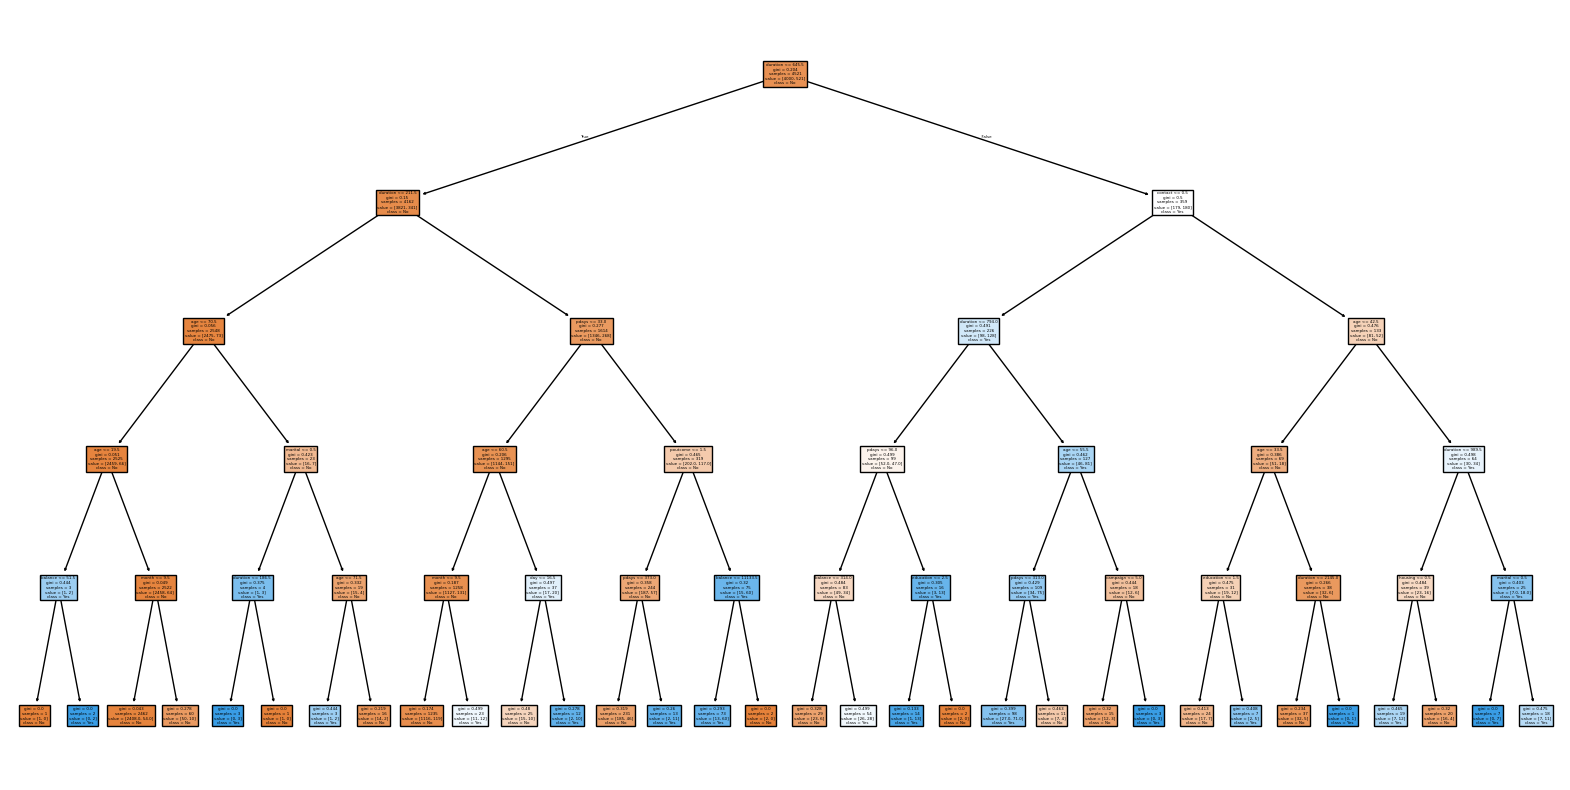

In [11]:

def visualize_tree(model, feature_names):
    tree_rules = export_text(model, feature_names=feature_names)
    print(tree_rules)
    
    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=feature_names, class_names=['No', 'Yes'], filled=True)
    plt.show()

# Visualize the tree using the training features
visualize_tree(dt_model, feature_names=X_train.columns)

## 5. Saving the Results

For future use and reproducibility, we save the evaluation metrics and the trained model to disk. The metrics are stored as a JSON file and the model is saved using joblib.

In [12]:
def save_results(metrics, model):
    with open('../metrics/decision_tree_metrics.json', 'w') as f:
        json.dump(metrics, f)
    
    joblib.dump(model, '../models/decision_tree.pkl')

# Save the metrics and model
save_results(metrics, dt_model)
print('Results and model saved successfully.')

Results and model saved successfully.


## Conclusion

In this notebook, we:

- Loaded and preprocessed the training and test datasets.
- Trained a Decision Tree Classifier with a maximum depth of 5.
- Evaluated the model using several performance metrics.
- Visualized the decision tree to understand its rules and structure.
- Saved both the evaluation results and the trained model.

This step-by-step process not only builds the model but also provides insight into each stage of the workflow.